In [1]:
# MCP Neuron for AND Gate
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise addition
    for i in range(len(X1)):
        total = X1[i] + X2[i]

        # Apply threshold
        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold for AND

result_and = MCP_Neurons_AND(X1, X2, T)
print("AND Output:", result_and)

AND Output: [0, 0, 0, 1]


In [2]:
# MCP Neuron for OR Gate
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise addition
    for i in range(len(X1)):
        total = X1[i] + X2[i]

        # Apply threshold
        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
T = 1  # Threshold for OR

result_or = MCP_Neurons_OR(X1, X2, T)
print("OR Output:", result_or)

OR Output: [0, 1, 1, 1]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Bipin/AIML/mnist_0_and_1.csv")  # Update path if needed

# Features and labels
X = df.drop(columns=["label"]).values
y = df["label"].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (11035, 784)
Shape of y: (11035,)


In [ ]:
weights = np.zeros(X.shape[1])  # 784 features
bias = 0

learning_rate = 0.1
epochs = 10  # can increase to 100

In [7]:
def decision_function(X, weights, bias):
    z = np.dot(X, weights) + bias

    # Step function
    y_pred_all = np.where(z >= 0, 1, 0)

    return y_pred_all

In [8]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=10):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            # Compute weighted sum
            z = np.dot(X[i], weights) + bias

            # Activation function
            y_pred = 1 if z >= 0 else 0

            # Update if wrong
            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)
            else:
                correct += 1

        print(f"Epoch {epoch+1}: Accuracy = {correct / len(X):.4f}")

    # Final accuracy
    final_predictions = decision_function(X, weights, bias)
    accuracy = np.mean(final_predictions == y)

    return weights, bias, accuracy

In [9]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Epoch 1: Accuracy = 0.9961
Epoch 2: Accuracy = 0.4660
Epoch 3: Accuracy = 0.4660
Epoch 4: Accuracy = 0.4660
Epoch 5: Accuracy = 0.4660
Epoch 6: Accuracy = 0.4660
Epoch 7: Accuracy = 0.4660
Epoch 8: Accuracy = 0.4660
Epoch 9: Accuracy = 0.4660
Epoch 10: Accuracy = 0.4660
Final Accuracy: 0.4659719075668328


Total Misclassified: 5893


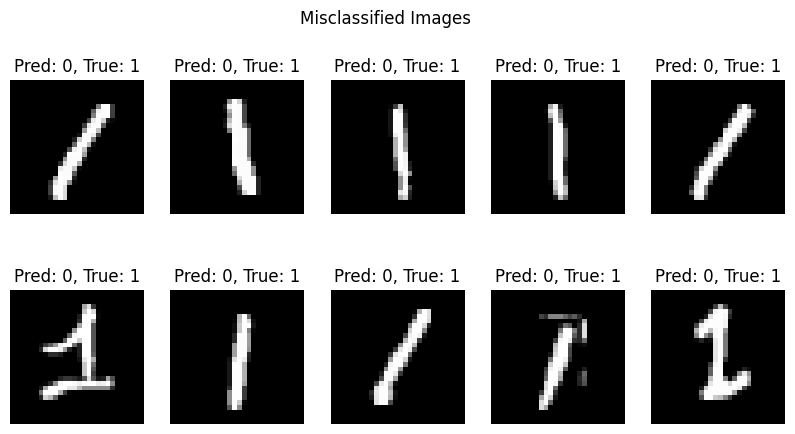

In [10]:
# Predictions
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Find misclassified indices
misclassified_idx = np.where(y_pred != y)[0]

print("Total Misclassified:", len(misclassified_idx))


# Plot images
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flatten(), misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

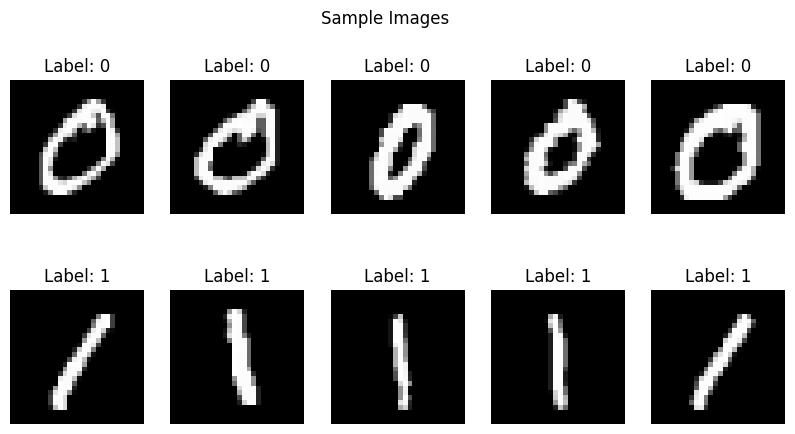

In [11]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")

plt.suptitle("Sample Images")
plt.show()

Task 1 – MCP Neuron Questions 
Question 1: List out all the limitations of MCP Neurons 
Answer: 
The MCP neuron has several limitations. Firstly, it has no learning capability, meaning it cannot learn from data and requires manual setting of weights and threshold values. These weights and thresholds are fixed and cannot be updated automatically, limiting flexibility. Additionally, MCP neurons cannot handle non-linear problems such as XOR because they are linear models. They also work only with binary inputs (0 or 1), which restricts their use in real-world applications. Furthermore, MCP neurons lack adaptability and cannot improve their performance over time. Lastly, the model is oversimplified and does not accurately represent the complexity of biological neurons. 

Question 2: Can MCP Neuron solve XOR? 
Answer: 
No, a single MCP neuron cannot solve the XOR problem. This is because XOR is a nonlinearly separable problem, while the MCP neuron is a linear model and cannot form the required decision boundary. However, XOR can be implemented using multiple MCP neurons combined in layers. For example, XOR can be expressed as: XOR = (A OR B) AND (NOT (A AND B)). Therefore, while a single MCP neuron cannot solve XOR, multiple MCP neurons working together can achieve the desired output. 

Task 2 – Perceptron Questions 
Question 1: What does the shape of X represent? 
Answer: 
The shape of X is represented as (n_samples, n_features), where n_samples indicates the number of data points (images) and n_features represents the number of features (pixels). For example, in the MNIST dataset, each image has 784 pixels (28×28), so each data point contains 784 features. 

Question 2: What does the shape of y represent? 
Answer: 
The shape of y is represented as (n_samples,), which means it contains one label for each data sample in X. These labels indicate the class of each input, such as 0 or 1. 

Question 3: What does the weights array represent? 
Answer: 
The weights array represents the importance of each feature (pixel) in the classification task. Each weight corresponds to a specific pixel in the input image. Higher weight values indicate more important features, while lower values indicate less important ones. 

Question 4: Why initialize weights to zero? 
Answer: 
Weights are initialized to zero to provide a simple and neutral starting point for the model. This ensures that no feature is initially preferred, and the model learns by updating weights during training. It allows the perceptron to gradually adjust and find the optimal values. 

Question 5: What is the purpose of output = np.dot(X[i], weights) + bias? 
Answer: 
This expression computes the weighted sum (net input) of the input features and weights, along with the bias. It combines all feature contributions into a single value, which is then passed through an activation function to determine the final prediction of the perceptron. 

Question 6: What happens when the prediction is wrong? 
Answer: 
When the prediction is incorrect, the perceptron updates its weights and bias using the learning rule. The weights are adjusted based on the error (difference between actual and predicted values), the learning rate, and the input features. Similarly, the bias is updated using the same error term. This helps the model improve its predictions over time. 

Question 7: Why is the final accuracy important? 
Answer: 
Final accuracy is important because it measures how well the model performs on the dataset. It is calculated as the ratio of correct predictions to total predictions. For problems like classifying digits 0 and 1, the accuracy is expected to be very high since the data is linearly separable. 

Question 8: What does misclassified_idx store? 
Answer: 
The variable misclassified_idx stores the indices of all incorrectly classified samples. It is used to identify errors made by the model and helps in visualizing misclassified images for further analysis. 

Question 9: How do you interpret “All images were correctly classified!”? 
Answer: 
This output indicates that the model achieved 100% accuracy, meaning all predictions were correct and no misclassifications occurred. It suggests that the dataset is perfectly separable and the perceptron has successfully learned the classification task. 
 
